In [1]:
import spikeinterface.full as si
import probeinterface as pif
import numpy as np
from probeinterface.plotting import plot_probe
import matplotlib.pyplot as plt
import scipy.io as scio
import os
import json
import re

In [2]:
%matplotlib widget

# Ideally you want to run Catgt at this point, if you haven't already
```
C:\CatGT-win/CatGT.exe -dir=D:\NPX_Data\M465\sourcedata\sub-M465 -run=M465-2024-01-31 -g=0 -t=0 -prb_fld -t_miss_ok -ni -ap -prb=0 -dest=D:\NPX_Data\M465\custom_preprocessed\M465-2024-01-31
```
For a 2 probe session, the command changes slightly
```
C:\CatGT-win/CatGT.exe -dir=D:\NPX_Data\OdorPixels\Pilot1\M465\sourcedata\sub-M465 -run=M465-2024-02-02 -g=0 -t=0 -prb_fld -t_miss_ok -ni -ap -prb='0,1' -dest=D:\NPX_Data\OdorPixels\Pilot1\M465\preprocessed\M465-2024-02-02
```
- VERY IMPORTANT!! Do not apply global CAR to be able to use LFPs later
- Adding the option `-no_autosync` will not extract the sync file stamps from the nidq, or the imec streams
- Set the destination to a different folder, outside of the parent folder, because spikeinterface can't read when t0 and tcat files are inside the same folder. Optionally do not set the `-dest` parameter, and just delete the *g0_t0.imec.ap.bin
- The 'run' parameter must not include "g0"
- The destination folder must not exist, but the its parent folder must (In this case D:\NPX_data\M483 should exist, but **NOT** D:\NPX_data\M483\M483-2024-01-22_tcat)


Text(0.5, 1.0, 'NPX 2')

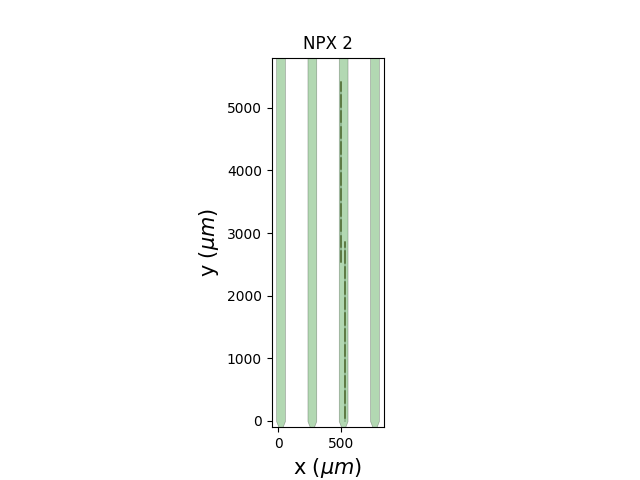

In [3]:
# path to meta file
meta_filename = 'E:\\STNPilot\\M511\\catgt_M511-2024-11-14_g0\\M511-2024-11-14_g0_tcat.imec0.ap.meta'
probe = pif.read_spikeglx(meta_filename)
fig,ax = plt.subplots()
plot_probe(probe, ax=ax)
ax.set_aspect(0.5) # Change depending on the probe
ax.set_ylim([-100, 5800]) # Change depending on the probe
ax.set_title('NPX 2') # Change depending on the probe


In [4]:
# Should point to the folder containing the tcat-ed .bin files
raw_rec = si.read_spikeglx('E:\\STNPilot\\M511\\catgt_M511-2024-11-14_g0', stream_name='imec0.ap')

In [5]:
# raw_rec = si.phase_shift(raw_rec) # DO NOT APPLY phase_shift it tcat has already been applied
rec1 = si.highpass_filter(raw_rec, freq_min=400.)
# bad_channel_ids, channel_labels = si.detect_bad_channels(rec1)
# print('bad_channel_ids, channel_labels')
# for bad_channel_id in bad_channel_ids:
#     index = int(bad_channel_id.split('AP')[1])
#     print('{}, {}'.format(bad_channel_id, channel_labels[index]))


In [8]:
# Edit the bad_channel_ids array after cross-checking in SpiukeGLX viewer
# Channels labeled 'out' make sense in this case, not sure about the one marked 'dead'
bad_channel_ids = np.asarray(['imec0.ap#AP9', 'imec0.ap#AP86', 'imec0.ap#AP139' ], dtype='U64')
bad_channel_ids

array(['imec0.ap#AP9', 'imec0.ap#AP86', 'imec0.ap#AP139'], dtype='<U64')

In [9]:
# Save the bad_channels as a json so that it can be loaded later
f = open('E:\\STNPilot\\M511\\catgt_M511-2024-11-14_g0\\imec0_bad_channels.json', 'w')
json.dump({'bad_channel_ids':bad_channel_ids.tolist()}, f, indent=4)
f.close()

In [10]:
# Load from the json file
f = open('E:\\STNPilot\\M511\\catgt_M511-2024-11-14_g0\\imec0_bad_channels.json', 'r')
bad_channel_ids = json.load(f)['bad_channel_ids']
f.close()
rec1  = rec1.remove_channels(bad_channel_ids)

### Setup Kilosort4 parameters 

In [ ]:
ks4_params = si.get_default_sorter_params('kilosort4')
ks4_params

In [ ]:
# Make any changes if needed to these params before dumping to json, example: ks2_params['detect_threshold'] = 4
ks4_params['delete_recording_dat'] = True
ks4_params['use_binary_file'] = True

## Running Kilosort locally

In [ ]:
si_working_folder = '/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/'
job_kwargs = dict(n_jobs=40, chunk_duration='1s', progress_bar=True)
rec1 = rec1.save(folder=si_working_folder + 'si_preprocess', format='binary', **job_kwargs)

In [ ]:
ks_working_folder = '/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/'
si.run_sorter('kilosort4', rec1, folder=ks_working_folder+'ks4_output', verbose=True, remove_existing_folder=False, **ks4_params )

##  Do manual sorting using phy

In [11]:
# The path should point to the folder that contains phy output
this_rec = rec1 # rec1 is the filtered recording, with the bad channels removed
sorting = si.KiloSortSortingExtractor(folder_path='E:\\STNPilot\\M511\\M511-2024-11-14\\ks4_output\\sorter_output')
sorting

KiloSortSortingExtractor: 680 units - 1 segments - 30.0kHz

In [ ]:
# # Code snippet to check if the last spike time is within the duration of the recording
# x = sorting.get_non_empty_unit_ids()
# Sfq = sorting.get_sampling_frequency()
# last_spike = [np.max(sorting.get_unit_spike_train(y))//Sfq for y in x]
# np.where(last_spike > this_rec.get_total_duration())[0]

In [13]:
# Run the following cell **ONLY** if the notebook was restarted after manual curation

# # This has to match the the details from temp_wh.dat, which is the binary file written
# # by Kilosort. This has to be appended with the appropriate channel ids and channel_locations
# # using rec that has the bad channels removed
this_rec  = si.read_binary('E:\\STNPilot\\M511\\M511-2024-11-14\\si_preprocess\\traces_cached_seg0.raw', sampling_frequency=rec1.get_sampling_frequency(), \
                           dtype='int16', num_channels=rec1.get_num_channels())
this_rec.annotate(is_filtered=rec1.is_filtered())
for key in rec1.get_property_keys():
    this_rec.set_property(key, rec1.get_property(key))
this_rec.set_channel_gains(rec1.get_channel_gains())
this_rec.set_probe(rec1.get_probe())
this_rec.annotate(probes_info=rec1.get_annotation('probes_info'))
this_rec.annotate(probe_0_planar_contour=rec1.get_annotation('probe_0_planar_contour'))
sorting.register_recording(this_rec)
assert rec1.get_total_duration() == this_rec.get_total_duration(), "There is probably a mismatch in the channel count in \
    the raw recording and the temp_file. Please check the channels included in both  the files"

## Collating information about clean cells

In [14]:
# KSlabel is Kilosort label, quality is user annotated
keep_idx = np.where(sorting.get_property('quality') == 'good')[0] # np.wher returns a tuple, so the extra '[0]'
keep_units = sorting.unit_ids[keep_idx]
clean_units = sorting.select_units(keep_units)
clean_units_ch = ['imec0.ap#AP' + str(x) for x in clean_units.get_property('ch')]
rec_ch = ['imec0.ap#' + str(x) for x in this_rec.get_property('channel_names')]
keep = [np.where(np.array(rec_ch) == x)[0].tolist() for x in clean_units_ch]
# This is a bug because 'bad channels' shouldn't be present in the first place
tokeep = [x for x,y in enumerate(keep) if y]
if len(tokeep) != len(keep):
    print('Bad channels are present in the clean units!! Weird!!')

keep_idx = keep_idx[np.asarray(tokeep)]
keep_units = sorting.unit_ids[keep_idx]
clean_units = sorting.select_units(keep_units)
clean_units_ch = ['imec0.ap#AP' + str(x) for x in clean_units.get_property('ch')]
rec_ch = ['imec0.ap#' + str(x) for x in this_rec.get_property('channel_names')]
keep = [np.where(np.array(rec_ch) == x)[0][0] for x in clean_units_ch]
clean_spike_train = [clean_units.get_unit_spike_train(x)/clean_units.get_sampling_frequency() \
    for x in clean_units.unit_ids]
clean_unit_ids = [str(x) for x in keep_units]
clean_unit_ids = ['imec0_'+x for x in clean_unit_ids]
clean_depths = clean_units.get_property('depth')
all_locs = this_rec.get_channel_locations()
# final_depths = [x[1] for x in all_locs[keep]] # There seems to be an offset between this and the depth from sorting.get_depths()
clean_unit_sh = [int(x[0]//250) for x in all_locs[keep]]
# assert (np.all(clean_unit_sh == this_rec.get_channel_groups()[keep])) # Sanity check

### The below code is to extract the waveforms of the curated neurons (might take some time to run)

In [16]:
si.set_global_job_kwargs(n_jobs=-1, progress_bar=True)
job_kwargs = dict(n_jobs=1, chunk_duration='1s', progress_bar=True)
analyzer = si.create_sorting_analyzer(sorting=clean_units, recording=this_rec, folder="E:\\STNPilot\\M511\\M511-2024-11-14\\clean_sorting", format="binary_folder", sparse=True)
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("spike_amplitudes", peak_sign="pos")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
clean_peak_amp = [amps_data[0][x] for x in clean_units.unit_ids]
wv = analyzer.get_extension(extension_name="waveforms")
clean_waveforms = [np.mean(wv.get_waveforms_one_unit(x), axis=0).T for x in clean_units.unit_ids]
analyzer.delete_extension('spike_amplitudes')
analyzer.compute("spike_amplitudes", peak_sign="neg")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
clean_valley_amp = [amps_data[0][x] for x in clean_units.unit_ids]

estimate_sparsity:   0%|          | 0/1384 [00:00<?, ?it/s]

c:\Users\mvdmlab\miniconda3\envs\spikeinterface\lib\site-packages\spikeinterface\core\basesorting.py:264: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms:   0%|          | 0/1384 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/1384 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/1384 [00:00<?, ?it/s]

### Saving as mat-files

In [17]:
# Saving everything
spikes_mat_fname = 'E:\\STNPilot\\M511\\M511-2024-11-14\\clean_units_imec0.mat' # add imec0 or imec1 if 2 probes
scio.savemat(spikes_mat_fname, {'depths': clean_depths, 'unit_ids': clean_unit_ids, \
    'channel_ids': clean_units_ch, 'spike_train': clean_spike_train, 'shank_ids': clean_unit_sh,  'mean_waveforms': clean_waveforms, \
                               'peak_amp': clean_peak_amp, 'valley_amp': clean_valley_amp})

### Now for MUA

In [18]:
# KSlabel is Kilosort label, quality is user annotated
keep_idx = np.where(sorting.get_property('quality') == 'mua')[0] # np.wher returns a tuple, so the extra '[0]'
keep_units = sorting.unit_ids[keep_idx]
mua_units = sorting.select_units(keep_units)
mua_units_ch = ['imec0.ap#AP' + str(x) for x in mua_units.get_property('ch')]
rec_ch = ['imec0.ap#' + str(x) for x in this_rec.get_property('channel_names')]
keep = [np.where(np.array(rec_ch) == x)[0].tolist() for x in mua_units_ch]
# This is a bug because 'bad channels' shouldn't be present in the first place
tokeep = [x for x,y in enumerate(keep) if y]
if len(tokeep) != len(keep):
    print('Bad channels are present in the MUA units!! Weird!!')

keep_idx = keep_idx[np.asarray(tokeep)]
keep_units = sorting.unit_ids[keep_idx]
mua_units = sorting.select_units(keep_units)
mua_units_ch = ['imec0.ap#AP' + str(x) for x in mua_units.get_property('ch')]
rec_ch = ['imec0.ap#' + str(x) for x in this_rec.get_property('channel_names')]
keep = [np.where(np.array(rec_ch) == x)[0][0] for x in mua_units_ch]
mua_spike_train = [mua_units.get_unit_spike_train(x)/mua_units.get_sampling_frequency() \
    for x in mua_units.unit_ids]
mua_unit_ids = [str(x) for x in keep_units]
mua_unit_ids = ['imec0_'+x for x in mua_unit_ids]
mua_depths = mua_units.get_property('depth')
all_locs = this_rec.get_channel_locations()
# final_depths = [x[1] for x in all_locs[keep]] # There seems to be an offset between this and the depth from sorting.get_depths()
mua_unit_sh = [int(x[0]//250) for x in all_locs[keep]]
# assert (np.all(mua_unit_sh == this_rec.get_channel_groups()[keep])) # Sanity check

### The below code is to extract the waveforms of MUA units, might take a while to run

In [19]:
job_kwargs = dict(n_jobs=1, chunk_duration='1s', progress_bar=True)
analyzer = si.create_sorting_analyzer(sorting=mua_units, recording=this_rec, folder="E:\\STNPilot\\M511\\M511-2024-11-14\\mua_sorting", format="binary_folder", sparse=True)
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("spike_amplitudes", peak_sign="pos")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
mua_peak_amp = [amps_data[0][x] for x in mua_units.unit_ids]
wv = analyzer.get_extension(extension_name="waveforms")
mua_waveforms = [np.mean(wv.get_waveforms_one_unit(x), axis=0).T for x in mua_units.unit_ids]
analyzer.delete_extension('spike_amplitudes')
analyzer.compute("spike_amplitudes", peak_sign="neg")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
mua_valley_amp = [amps_data[0][x] for x in mua_units.unit_ids]

estimate_sparsity:   0%|          | 0/1384 [00:00<?, ?it/s]

compute_waveforms:   0%|          | 0/1384 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/1384 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/1384 [00:00<?, ?it/s]

In [20]:
# Saving everything
spikes_mat_fname = 'E:\\STNPilot\\M511\\M511-2024-11-14\\mua_units_imec0.mat' # add imec0 or imec1 if 2 probes
scio.savemat(spikes_mat_fname, {'depths': mua_depths, 'unit_ids': mua_unit_ids, \
    'channel_ids': mua_units_ch, 'spike_train': mua_spike_train, 'shank_ids': mua_unit_sh,  'mean_waveforms': mua_waveforms, \
                               'peak_amp': mua_peak_amp, 'valley_amp': mua_valley_amp})

# Run the following if there is a second probe

Text(0.5, 1.0, 'NPX 2')

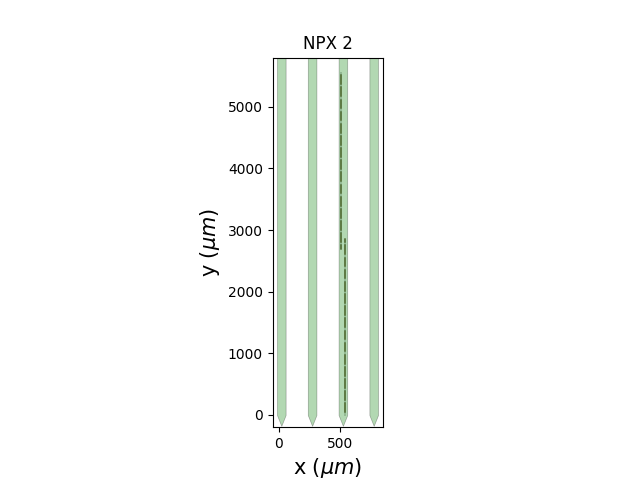

In [4]:
# path to meta file
meta_filename = 'E:\\STNPilot\\M511\\catgt_M511-2024-11-14_g0\\M511-2024-11-14_g0_tcat.imec1.ap.meta'
probe = pif.read_spikeglx(meta_filename)
fig,ax = plt.subplots()
plot_probe(probe, ax=ax)
ax.set_aspect(0.5) # Change depending on the probe
ax.set_ylim([-200, 5800]) # Change depending on the probe
ax.set_title('NPX 2') # Change depending on the probe


In [3]:
# Should point to the folder containing the tcat-ed .bin files
raw_rec2 = si.read_spikeglx('E:\\STNPilot\\M511\\catgt_M511-2024-11-14_g0\\', stream_name='imec1.ap')

In [4]:
# raw_rec2 = si.phase_shift(raw_rec2) # DO NOT APPLY phase_shift it tcat has already been applied
rec2 = si.highpass_filter(raw_rec2, freq_min=400.)
bad_channel_ids2, channel_labels2 = si.detect_bad_channels(rec2)
print('bad_channel_ids, channel_labels')
for bad_channel_id in bad_channel_ids2:
    index = int(bad_channel_id.split('AP')[1])
    print('{}, {}'.format(bad_channel_id, channel_labels2[index]))

In [ ]:
# Edit the bad_channel_ids array after cross-checking in SpiukeGLX viewer
# Channels labeled 'out' make sense in this case, not sure about the one marked 'dead'
# new_array2 = bad_channel_ids2
# new_array = np.append(new_array2, 'imec0.ap#AP100')
# print(new_array2)
# bad_channel_ids2 = new_array2
bad_channel_ids2 = np.asarray([], dtype='U64')
bad_channel_ids2

In [ ]:
# Save the bad_channels as a json so that it can be loaded later
f = open('/home/manishm/data/odor-pixels/M542/catgt_M542-2024-11-09_g0/imec1_bad_channels.json', 'w')
json.dump({'bad_channel_ids':bad_channel_ids2.tolist()}, f, indent=4)
f.close()

In [ ]:
# Load from the json file
f = open('/home/manishm/data/odor-pixels/M542/catgt_M542-2024-11-09_g0/imec1_bad_channels.json', 'r')
bad_channel_ids2 = json.load(f)['bad_channel_ids']
f.close()
rec2  = rec2.remove_channels(bad_channel_ids2)

### Setup Kilosort4 parameters 

In [ ]:
ks4_params = si.get_default_sorter_params('kilosort4')
ks4_params

In [ ]:
# Make any changes if needed to these params before dumping to json, example: ks2_params['detect_threshold'] = 4
ks4_params['delete_recording_dat'] = True
ks4_params['use_binary_file'] = True

### Running Kilosort locally

In [ ]:
si_working_folder = '/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/'
job_kwargs = dict(n_jobs=20, chunk_duration='1s', progress_bar=True)
rec2 = rec2.save(folder=si_working_folder + 'si_preprocess2', format='binary',overwrite=True, **job_kwargs)

In [ ]:
ks_working_folder = '/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/'
si.run_sorter('kilosort4', rec2, folder=ks_working_folder+'ks4_output2', verbose=True, remove_existing_folder=False, **ks4_params )

## TPrime adjustment of 2nd probe spike times

- Convert the spike_times.npy into timestamps from samples
- Use TPrime to adjust these 'timestamps'
- Convert adjusted timestamps back to samples for phy curation

In [ ]:
# Convert spike_times (samples) to spike_timestamps
ks_outpath = '/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/ks4_output2/sorter_output/' # Path to where Kilosort's outputs live
spike_timestamps = np.load(ks_outpath+'spike_times.npy') * raw_rec2.get_sampling_frequency()
np.save(ks_outpath + 'spike_timestamps.npy', spike_timestamps)

C:\TPrime-win/TPrime.exe -syncperiod='1.0' -tostream='/home/manishm/data/odor-pixels/M542/catgt_M542-2024-11-09_g0/M542-2024-11-09_g0_tcat.imec0.ap.xd_384_6_500.txt' -fromstream='5,/home/manishm/data/odor-pixels/M542/catgt_M542-2024-11-09_g0/M542-2024-11-09_g0_tcat.imec1.ap.xd_384_6_500.txt' -events='5,/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/ks4_output2/sorter_output/spike_timestamps.npy,/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/ks4_output2/sorter_output/adj_spike_timestamps.npy'

### For Linux, replace .exe with <TPrime_path>/runit.sh

In [ ]:
# Convert new_spike_timestamps (seconds) to samples to work with Phy
ks_outpath = '/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/ks4_output2/sorter_output/' # Path to where Kilosort's outputs live
spike_times = np.load(ks_outpath+'adj_spike_timestamps.npy') / raw_rec2.get_sampling_frequency()
np.save(ks_outpath + 'new_spike_times.npy', spike_times)

### Cleanup
- Rename spike_times.npy to old_spike_times.npy
- Rename new_spike_times.npy to spike_times.npy 
- Delete 'spike_timestamps.npy' and 'adj_spike_timestamps.npy'

## Do Manual curation using phy

In [6]:
# The path should point to the folder that contains phy output
this_rec2 = rec2 # rec2 is the filtered recording, with the bad channels removed
sorting2 = si.KiloSortSortingExtractor(folder_path='E:\\STNPilot\\M511\\M511-2024-11-14\\ks4_output2\\sorter_output')
sorting2

KiloSortSortingExtractor: 475 units - 1 segments - 30.0kHz

In [7]:
# Run the following cell **ONLY** if the notebook was restarted after manual curation

# This has to match the the details from temp_wh.dat, which is the binary file written
# by Kilosort. This has to be appended with the appropriate channel ids and channel_locations
# using rec2 that has the bad channels removed
this_rec2  = si.read_binary('E:\\STNPilot\\M511\\M511-2024-11-14\\si_preprocess2\\traces_cached_seg0.raw', sampling_frequency=rec2.get_sampling_frequency(), \
                           dtype='int16', num_channels=rec2.get_num_channels())
this_rec2.annotate(is_filtered=rec2.is_filtered())
for key in rec2.get_property_keys():
    this_rec2.set_property(key, rec2.get_property(key))
this_rec2.set_channel_gains(rec2.get_channel_gains())
this_rec2.set_probe(rec2.get_probe())
this_rec2.annotate(probes_info=rec2.get_annotation('probes_info'))
this_rec2.annotate(probe_0_planar_contour=rec2.get_annotation('probe_0_planar_contour'))
sorting2.register_recording(this_rec2)
assert rec2.get_total_duration() == this_rec2.get_total_duration(), "There is probably a mismatch in the channel count in \
    the raw recording and the temp_file. Please check the channels included in both  the files"


## Collating information about clean cells

In [8]:
# KSlabel is Kilosort label, quality is user annotated
keep_idx2 = np.where(sorting2.get_property('quality') == 'good')[0] # np.wher returns a tuple, so the extra '[0]'
keep_units2 = sorting2.unit_ids[keep_idx2]
clean_units2 = sorting2.select_units(keep_units2)
clean_units_ch2 = ['imec1.ap#AP' + str(x) for x in clean_units2.get_property('ch')]
rec_ch2 = ['imec1.ap#' + str(x) for x in this_rec2.get_property('channel_names')]
keep2 = [np.where(np.array(rec_ch2) == x)[0].tolist() for x in clean_units_ch2]
# This is a bug because 'bad channels' shouldn't be present in the first place
tokeep2 = [x for x,y in enumerate(keep2) if y]
if len(tokeep2) != len(keep2):
    print('Bad channels are present in the clean units!! Weird!!')

keep_idx2 = keep_idx2[np.asarray(tokeep2)]
keep_units2 = sorting2.unit_ids[keep_idx2]
clean_units2 = sorting2.select_units(keep_units2)
clean_units_ch2 = ['imec1.ap#AP' + str(x) for x in clean_units2.get_property('ch')]
rec_ch2 = ['imec1.ap#' + str(x) for x in this_rec2.get_property('channel_names')]
keep2 = [np.where(np.array(rec_ch2) == x)[0][0] for x in clean_units_ch2]
clean_spike_train2 = [clean_units2.get_unit_spike_train(x)/clean_units2.get_sampling_frequency() \
    for x in clean_units2.unit_ids]
clean_unit_ids2 = [str(x) for x in keep_units2]
clean_unit_ids2 = ['imec1_'+x for x in clean_unit_ids2]
clean_depths2 = clean_units2.get_property('depth')
all_locs2 = this_rec2.get_channel_locations()
# final_depths2 = [x[1] for x in all_locs2[keep2]] # There seems to be an offset between this and the depth from sorting2.get_depths()
clean_unit_sh2 = [int(x[0]//250) for x in all_locs2[keep2]]
# assert (np.all(clean_unit_sh2 == this_rec2.get_channel_groups()[keep2])) # Sanity check

### The below code is to extract the waveforms of the curated neurons (might take some time to run)

In [9]:
si.set_global_job_kwargs(n_jobs=-1, progress_bar=True)
job_kwargs = dict(n_jobs=1, chunk_duration='1s', progress_bar=True)
analyzer = si.create_sorting_analyzer(sorting=clean_units2, recording=this_rec2, \
    folder="E:\\STNPilot\\M511\\M511-2024-11-14\\clean_sorting2", format="binary_folder", sparse=True, overwrite=True)
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("spike_amplitudes", peak_sign="pos")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
clean_peak_amp2 = [amps_data[0][x] for x in clean_units2.unit_ids]
wv = analyzer.get_extension(extension_name="waveforms")
clean_waveforms2 = [np.mean(wv.get_waveforms_one_unit(x), axis=0).T for x in clean_units2.unit_ids]
analyzer.delete_extension('spike_amplitudes')
analyzer.compute("spike_amplitudes", peak_sign="neg")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
clean_valley_amp2 = [amps_data[0][x] for x in clean_units2.unit_ids]

estimate_sparsity:   0%|          | 0/1384 [00:00<?, ?it/s]

c:\Users\mvdmlab\miniconda3\envs\spikeinterface\lib\site-packages\spikeinterface\core\basesorting.py:264: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


compute_waveforms:   0%|          | 0/1384 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/1384 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/1384 [00:00<?, ?it/s]

In [10]:
# Saving everything
spikes_mat_fname2 = 'E:\\STNPilot\\M511\\M511-2024-11-14\\clean_units_imec1.mat' # add imec0 or imec1 if 2 probes
scio.savemat(spikes_mat_fname2, {'depths': clean_depths2, 'unit_ids': clean_unit_ids2, \
    'channel_ids': clean_units_ch2, 'spike_train': clean_spike_train2, 'shank_ids': clean_unit_sh2,  'mean_waveforms': clean_waveforms2, \
                               'peak_amp': clean_peak_amp2, 'valley_amp': clean_valley_amp2})

### Now for MUA

In [11]:
# KSlabel is Kilosort label, quality is user annotated
keep_idx2 = np.where(sorting2.get_property('quality') == 'mua')[0] # np.wher returns a tuple, so the extra '[0]'
keep_units2 = sorting2.unit_ids[keep_idx2]
mua_units2 = sorting2.select_units(keep_units2)
mua_units_ch2 = ['imec1.ap#AP' + str(x) for x in mua_units2.get_property('ch')]
rec_ch2 = ['imec1.ap#' + str(x) for x in this_rec2.get_property('channel_names')]
keep2 = [np.where(np.array(rec_ch2) == x)[0].tolist() for x in mua_units_ch2]
# This is a bug because 'bad channels' shouldn't be present in the first place
tokeep2 = [x for x,y in enumerate(keep2) if y]
if len(tokeep2) != len(keep2):
    print('Bad channels are present in the mua units!! Weird!!')

keep_idx2 = keep_idx2[np.asarray(tokeep2)]
keep_units2 = sorting2.unit_ids[keep_idx2]
mua_units2 = sorting2.select_units(keep_units2)
mua_units_ch2 = ['imec1.ap#AP' + str(x) for x in mua_units2.get_property('ch')]
rec_ch2 = ['imec1.ap#' + str(x) for x in this_rec2.get_property('channel_names')]
keep2 = [np.where(np.array(rec_ch2) == x)[0][0] for x in mua_units_ch2]
mua_spike_train2 = [mua_units2.get_unit_spike_train(x)/mua_units2.get_sampling_frequency() \
    for x in mua_units2.unit_ids]
mua_unit_ids2 = [str(x) for x in keep_units2]
mua_unit_ids2 = ['imec1_'+x for x in mua_unit_ids2]
mua_depths2 = mua_units2.get_property('depth')
all_locs2 = this_rec2.get_channel_locations()
# final_depths2 = [x[1] for x in all_locs2[keep2]] # There seems to be an offset between this and the depth from sorting2.get_depths()
mua_unit_sh2 = [int(x[0]//250) for x in all_locs2[keep2]]
# assert (np.all(mua_unit_sh2 == this_rec2.get_channel_groups()[keep2])) # Sanity check

### The code below extracts waveforms

In [12]:
job_kwargs = dict(n_jobs=1, chunk_duration='1s', progress_bar=True)
analyzer = si.create_sorting_analyzer(sorting=mua_units2, recording=this_rec2, \
    folder="E:\\STNPilot\\M511\\M511-2024-11-14\\mua_sorting2", format="binary_folder", sparse=True, overwrite=True)
analyzer.compute("random_spikes")
analyzer.compute("waveforms")
analyzer.compute("templates")
analyzer.compute("spike_amplitudes", peak_sign="pos")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
mua_peak_amp2 = [amps_data[0][x] for x in mua_units2.unit_ids]
wv = analyzer.get_extension(extension_name="waveforms")
mua_waveforms2 = [np.mean(wv.get_waveforms_one_unit(x), axis=0).T for x in mua_units2.unit_ids]
analyzer.delete_extension('spike_amplitudes')
analyzer.compute("spike_amplitudes", peak_sign="neg")
amps = analyzer.get_extension('spike_amplitudes')
amps_data = amps.get_data(outputs='by_unit')
mua_valley_amp2 = [amps_data[0][x] for x in mua_units2.unit_ids]

estimate_sparsity:   0%|          | 0/1384 [00:00<?, ?it/s]

compute_waveforms:   0%|          | 0/1384 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/1384 [00:00<?, ?it/s]

spike_amplitudes:   0%|          | 0/1384 [00:00<?, ?it/s]

In [13]:
# Saving everything
spikes_mat_fname2 = 'E:\\STNPilot\\M511\\M511-2024-11-14\\mua_units_imec1.mat' # add imec0 or imec1 if 2 probes
scio.savemat(spikes_mat_fname2, {'depths': mua_depths2, 'unit_ids': mua_unit_ids2, \
    'channel_ids': mua_units_ch2, 'spike_train': mua_spike_train2, 'shank_ids': mua_unit_sh2,  'mean_waveforms': mua_waveforms2, \
                                'peak_amp': mua_peak_amp2, 'valley_amp': mua_valley_amp2})

# MATLAB code to load the spikes into mvdmlab `LoadSpikes()` format
```
load('clean units.mat')
S = ts;
S.t  = cellfun(@(x) x', spike_train, 'UniformOutput', false); % This is important to convert the spiketrain into column format
S.label = cellstr(string(channel_ids).strip())'; % Ugly but works!
S.usr = [];
S.usr.recording_depths = depths; % Not sure if this is the best place to save this
S.usr.mean_waveforms = clean_waveforms % Not sure if this is the best place to save this
```



# LFP Extraction

### Extract downsampled and bandpass filtered LFPs based on a depth based measure

In [ ]:
lfp_rec = raw_rec.remove_channels(bad_channel_ids) # Remove the bad channels for this too
req_fs = 2500 # Hz
lfp_rec= si.resample(lfp_rec, req_fs)
lfp_rec = si.bandpass_filter(lfp_rec, freq_min=1, freq_max=400)

In [ ]:
# Automatic channel selection for NPX2
inter_shank_space = 250 # microns
req_spacing = 100 # microns
keep_idx = []
for iShank in range(4):
    idx_depth = [(idx,x[1]) for idx,x in enumerate(lfp_rec.get_channel_locations()) if int(x[0]//inter_shank_space) == iShank]
    # if no channels, skip
    if len(idx_depth) == 0:
        continue
    depths = [x[1] for x in idx_depth]
    idx = [x[0] for x in idx_depth]
    queried_depths =  np.arange(min(depths), max(depths), req_spacing).tolist()
    if queried_depths[-1] < max(depths)-50:
        queried_depths.append(max(depths))
    for b in queried_depths:
        min_diff = float('inf')
        closest_index = None   
        for i, a in enumerate(depths):
            diff = abs(a - b)
            if diff < min_diff:
                min_diff = diff
                closest_index = i
            elif diff == min_diff:
                closest_index = min(closest_index, i)
        keep_idx.append(idx[closest_index])
print(lfp_rec.channel_ids[keep_idx])

In [ ]:
# Manual selection code
# selected_channels = ['AP15', 'AP35', 'AP220'] # Make a list of channels based on the above widget or using spikeGLX Viewer
# keep_idx = [np.where(np.char.endswith(lfp_rec.channel_ids, x))[0] for x in selected_channels]
# lfp_rec.channel_ids[keep_idx]

In [ ]:
final_channels = lfp_rec.channel_ids[np.asarray(keep_idx)]
final_tvec = lfp_rec.get_times()
final_fs = lfp_rec.get_sampling_frequency()
all_locs = lfp_rec.get_channel_locations()
final_depths = [x[1] for x in all_locs[keep_idx]]
shank_ids = [int(x[0]//250) for x in all_locs[keep_idx]]

### This below cell may take some time to run

In [ ]:
## Best way to extract lfp 
temp_lfp = lfp_rec.save(channel_ids=final_channels, return_scaled=True, cast_unsigned=True, \
                        format="binary", folder="/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/temp_lfp", n_jobs=10, chunk_duration="1s") 
final_lfp = temp_lfp.get_traces(channel_ids=final_channels, return_scaled=True, cast_unsigned=True)

In [ ]:
# The old ways are soooo bad
# final_lfp = []
# for ch in final_channels:
#     print(ch)
#     final_lfp.append(lfp_rec.get_traces(channel_ids=[ch], return_scaled=True, cast_unsigned=True))
# final_lfp = lfp_rec.get_traces(channel_ids=final_channels, \
#     return_scaled=True, cast_unsigned=True)

In [ ]:
# Save the final_lfp and final_channels to a mat file
lfp_mat_fname = '/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/imec0_clean_lfp.mat'
scio.savemat(lfp_mat_fname, {'depths': final_depths, 'channel_ids': final_channels, \
    'lfp_traces': np.squeeze(np.asarray(final_lfp)), 'lfp_tvec': final_tvec, 'lfp_fs': final_fs, 'shank_ids': shank_ids})

### TODO:
- Interpolate the LFPs to match probe-1's timebase

## Run this if there is a second probe

### Extract downsampled and bandpass filtered LFPs based on a depth based measure

In [ ]:
lfp_rec2 = raw_rec2.remove_channels(bad_channel_ids2) # Remove the bad channels for this too
req_fs2 = 2500 # Hz
lfp_rec2= si.resample(lfp_rec2, req_fs2)
lfp_rec2 = si.bandpass_filter(lfp_rec2, freq_min=1, freq_max=400)

In [ ]:
# Create a timestamp file based on the resampled and filtered lfp and use TPrime to align them to probe 1's timebase
ts_outpath = '/home/manishm/data/odor-pixels/M542/preprocessed/catgt_M542-2024-11-09_g0/'
np.save(ts_outpath + 'imec1_lfp_times.npy', lfp_rec2.get_times())

C:\TPrime-win/TPrime.exe -syncperiod='1.0' -tostream='/home/manishm/data/odor-pixels/M542/preprocessed/catgt_M542-2024-11-09_g0/M542-2024-11-09_g0_tcat.imec0.ap.xd_384_6_500.txt' -fromstream='5,/home/manishm/data/odor-pixels/M542/preprocessed/catgt_M542-2024-11-09_g0/M542-2024-11-09_g0_tcat.imec1.ap.xd_384_6_500.txt' -events='5,/home/manishm/data/odor-pixels/M542/preprocessed/catgt_M542-2024-11-09_g0/imec1_lfp_times.npy,/home/manishm/data/odor-pixels/M542/preprocessed/catgt_M542-2024-11-09_g0/imec1_adj_lfp_times.npy'
### For Linux, replace .exe with <TPrime_path>/runit.sh

In [ ]:
adjusted_ts = np.load(ts_outpath + 'imec1_adj_lfp_times.npy')
old_ts = lfp_rec2.get_times()
len(adjusted_ts), len(old_ts)

In [ ]:
# Automatic channel selection for NPX2
inter_shank_space = 250 # microns
req_spacing = 100 # microns
keep_idx = []
for iShank in range(4):
    idx_depth = [(idx,x[1]) for idx,x in enumerate(lfp_rec2.get_channel_locations()) if int(x[0]//inter_shank_space) == iShank]
    # if no channels, skip
    if len(idx_depth) == 0:
        continue
    depths = [x[1] for x in idx_depth]
    idx = [x[0] for x in idx_depth]
    queried_depths =  np.arange(min(depths), max(depths), req_spacing).tolist()
    if queried_depths[-1] < max(depths)-50:
        queried_depths.append(max(depths))
    for b in queried_depths:
        min_diff = float('inf')
        closest_index = None   
        for i, a in enumerate(depths):
            diff = abs(a - b)
            if diff < min_diff:
                min_diff = diff
                closest_index = i
            elif diff == min_diff:
                closest_index = min(closest_index, i)
        keep_idx.append(idx[closest_index])
print(lfp_rec2.channel_ids[keep_idx])

In [ ]:
# Manual selection code
# selected_channels2 = ['AP15', 'AP35', 'AP220'] # Make a list of channels based on the above widget or using spikeGLX Viewer
# keep_idx = [np.where(np.char.endswith(lfp_rec.channel_ids, x))[0] for x in selected_channels]
# lfp_rec2.channel_ids[keep_idx]

In [ ]:
final_channels2 = lfp_rec2.channel_ids[np.asarray(keep_idx)]
final_tvec2 = adjusted_ts # NOT lfp_rec2.get_times()
final_fs2 = lfp_rec2.get_sampling_frequency()
all_locs2 = lfp_rec2.get_channel_locations()
final_depths2 = [x[1] for x in all_locs2[keep_idx]]
shank_ids2 = [int(x[0]//250) for x in all_locs2[keep_idx]]

In [ ]:
## Best way to extract lfp 
temp_lfp2 = lfp_rec2.save(channel_ids=final_channels2, return_scaled=True, cast_unsigned=True, \
                        format="binary", folder="/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/temp_lfp2", n_jobs=10, chunk_duration="1s") 
final_lfp2 = temp_lfp2.get_traces(channel_ids=final_channels2, return_scaled=True, cast_unsigned=True)

In [ ]:
# Old ways are sooo bad
# final_lfp2 = []
# for ch in final_channels2:
#     print(ch)
#     final_lfp2.append(lfp_rec2.get_traces(channel_ids=[ch], return_scaled=True, cast_unsigned=True))
# final_lfp2 = lfp_rec2.get_traces(channel_ids=final_channels2, \
#     return_scaled=True, cast_unsigned=True)

In [ ]:
# Save the final_lfp and final_channels to a mat file
lfp_mat_fname = '/home/manishm/data/odor-pixels/M542/preprocessed/M542-2024-11-09/imec1_clean_lfp.mat'
scio.savemat(lfp_mat_fname, {'depths': final_depths2, 'channel_ids': final_channels2, \
    'lfp_traces': np.squeeze(np.asarray(final_lfp2)), 'lfp_tvec': final_tvec2, 'lfp_fs': final_fs2, 'shank_ids': shank_ids2})


# MATLAB code to load LFPs into mvdmlab `LoadCSC()` format
```
csc = tsd;
load('clean_lfp.mat')
csc.tvec = lfp_tvec';
cfg = [];
csc.data = lfp_traces';
csc.label = cellstr(string(channel_ids).strip().extractAfter('ap#')'); % Ugly but works!
csc.cfg.depths = depths; % Not sure if this is the best place to save it
csc.cfg.Fs = lfp_fs; % Not sure if this is the best place to save it
```

# MATLAB code to sync LFPS from 2 probes
```
imec0 = load('imec0_clean_lfp.mat');
imec1 = load('imec1_clean_lfp.mat');

imec1.adj_traces = zeros(size(imec1.lfp_traces));
for iCh = 1:size(imec1.lfp_traces,2)
    imec1.adj_traces(:,iCh) = interp1(imec1.lfp_tvec', imec1.lfp_traces(:,iCh), imec0.lfp_tvec');
end
% imec1.adj_traces and imec0.lfp_traces are now on the unified timebase imec0.lfp_tvec
```

# CATGT way to extract events

## SpikeGLX reference:
```
-xa=0,0,2,3.0,4.5,25     ;extract pulse signal from analog chan (js,ip,word,thresh1(V),thresh2(V),millisec); For our purposes word = 0 for XA0, 1 for XA1 = 1 and so on
-xd=0,0,384,6,500        ;extract pulse signal from digital chan (js,ip,word,bit,millisec; For our purposes word = 0 always; bit = 0 for XD0, 1 for XD1 = 1 and so on)
-xia=0,0,2,3.0,4.5,2     ;inverted version of xa
-xid=0,0,384,6,50        ;inverted version xd
```

***IMPORTANT***: Milliseconds duration can be zero to specify detection of all leading edges regardless of pulse duration

In [14]:
# Teensy generated pulses are all in the range 0-3.3 V, but the thresolds will change depending on what is being generated
# Create dictionary called analog channels, with channel name as 'key' and (thresh1, thresh2) as 'value'
analog_channels = {'XA0': [1, 3], 'XA1': [1, 3], 'XA2': [1, 3], 'XA3': [1, 3], 'XA4': [1, 3], 'XA5': [1, 3], 'XA6': [1, 3], 'XA7': [1, 3]}
# Create list of digital channels, for example, digital_channels = ['XD0', 'XD1']
digital_channels = ['XD2', 'XD3'] 
num_analog_channels = 8

In [ ]:
# Other parameters
catgt_path = 'C:\\CatGT-win' # The location where CatGT.exe exists
source_path = 'F:\\NPX_Data\\OdorPixels\\Task2_SWR\\M541\\rawdata\\' # The parent directory of the session folder
run_name = 'M541-2024-09-05' # The thing that is suffixed by the top level 'g0' folder
dest_path = 'E:\\M541\\preprocessed\\M541-2024-09-05\\' # Where catgt's output files will reside

In [ ]:
command_prefix = '{}/CatGT.exe -dir={} -run={} -g=0 -t=0 -prb_fld -t_miss_ok -ni'.format(catgt_path, source_path, run_name)
print(command_prefix)

In [ ]:
# generate arguments to find rising and falling edges in analog channels
analog_params = '';
for key in analog_channels:
    analog_params += '-xa=\'0,0,{},{},{},0\' -xia=\'0,0,{},{},{},0\' '.format(key[2:],analog_channels[key][0], analog_channels[key][1], \
    key[2:],analog_channels[key][0], analog_channels[key][1])
print(analog_params)

In [ ]:
# generate arguments to find rising and falling edges in digital channels
digital_params = '';
for item in digital_channels:
    digital_params += '-xd=\'0,0,{},{},0\' -xid=\'0,0,{},{},0\' '.format(num_analog_channels, item[2:], num_analog_channels, item[2:])
print(digital_params)

In [ ]:
command_suffix = '-dest={}'.format(dest_path)
print(command_suffix)

In [ ]:
# Final command to be copy-pasted
print('{} {} {} {}'.format(command_prefix, analog_params, digital_params, command_suffix))

**If it worked, then you will see a catgt-XXYY folder created at the destination folder, if it didn't already exist when you ran the catgt to tshift on the AP files.**

**Otherwise check CatGT.log in the window that you ran the command from.**

### TPrime command generator to align events

In [ ]:
# Parameters
to_probe = 'imec0' #
tprime_path = 'C:\\TPrime-win' # Location where TPrime.exe lives
tsource_path = 'E:\\M541\\preprocessed\\M541-2024-09-05\\catgt_M541-2024-09-05_g0\\' # Location where all sync pulses and edge extraction files live
tdest_path = 'E:\\M541\\preprocessed\\M541-2024-09-05\\'# Location where you want the Tprime output files to go

In [ ]:
# Analog and digital channels to be synced
analog_channels = ['XA0', 'XA1', 'XA2', 'XA3', 'XA4', 'XA5', 'XA6', 'XA7']
digital_channels = ['XD2', 'XD3']

In [ ]:
# Parameter sanity checker
file_list = []
for root, dirs, files in os.walk(tsource_path):
    for file in files:
       file_list.append(file)
to_file = [x for x in file_list if to_probe in x and '.txt' in x]
assert len(to_file) == 1, 'Something wrong with to-stream, expected 1 file, found {}'.format(to_file)
from_file = [x for x in file_list if 'nidq.xd' in x and '500.txt' in x]
assert len(from_file) == 1, 'Something wrong with from-stream, expected 1 file, found {}'.format(from_file)
analog_in_files = []
analog_out_files = []
for ch in analog_channels:
    this_on_file = [x for x in file_list if 'nidq.xa_'+ch[2:] in x and '0.txt' in x]
    assert len(this_on_file) == 1, 'Something wrong with ON events from channel {}, expected 1, found {}'.format(ch, this_on_file)
    analog_in_files.extend(this_on_file)
    analog_out_files.append(ch+'_ON.txt')
    this_off_file = [x for x in file_list if 'nidq.xia_'+ch[2:] in x and '0.txt' in x]
    assert len(this_off_file) == 1, 'Something wrong with OFF events from channel {}, expected 1, found {}'.format(ch, this_off_file)
    analog_in_files.extend(this_off_file)
    analog_out_files.append(ch+'_OFF.txt')
print(analog_in_files)
print(analog_out_files)
digital_in_files = []
digital_out_files = []
for ch in digital_channels:
    this_on_file = [x for x in file_list if 'nidq.xd' in x and ch[2:]+'_0.txt' in x]
    assert len(this_on_file) == 1, 'Something wrong with ON events from channel {}, expected 1, found {}'.format(ch, this_on_file)
    digital_in_files.extend(this_on_file)
    digital_out_files.append(ch+'_ON.txt')
    this_off_file = [x for x in file_list if 'nidq.xid' in x and ch[2:]+'_0.txt' in x]
    assert len(this_off_file) == 1, 'Something wrong with OFF events from channel {}, expected 1, found {}'.format(ch, this_off_file)
    digital_in_files.extend(this_off_file)
    digital_out_files.append(ch+'_OFF.txt')  
print(digital_in_files)
print(digital_out_files)

In [ ]:
#The stream number is arbitrary (5 in this case)
tcommand_prefix = '{}/TPrime.exe -syncperiod=\'1.0\' -tostream=\'{}{}\' -fromstream=\'5,{}{}\''.format(\
    tprime_path, tsource_path, to_file[0], tsource_path, from_file[0])
print(tcommand_prefix)

In [ ]:
events_params = ''
for f_in, f_out in zip(analog_in_files, analog_out_files):
    events_params += '-events=\'5,{}{},{}{}\' '.format(tsource_path, f_in, tdest_path, f_out)
for f_in, f_out in zip(digital_in_files, digital_out_files):
    events_params += '-events=\'5,{}{},{}{}\' '.format(tsource_path, f_in, tdest_path, f_out)
print(events_params)

In [ ]:
# Final command to be copy-pasted in a powershell prompt
print('{} {}'.format(tcommand_prefix, events_params))

**If it worked, then you will see the desired output files created at the destination folder.**

**Otherwise check TPrime.log in the window that you ran the command from.**

In [ ]:
# Get the ON and off times for each of the required channels
nidq_channels = ['XA0', 'XA1', 'XA2', 'XA3', 'XA4', 'XA5'] # 'XD0', 'XD1', ... for digital channels
input_path = 'D:\\NPX_Data\\OdorPixels\\Pilot1\\M481\\preprocessed\\M481-2024-01-15\\' # where XA1_ON etc live


In [ ]:
flist = os.listdir(input_path)
event_dict = {}
for ch in nidq_channels:
    events = [x for x in flist if ch in x]
    for ev in events:
        event_dict[ev[:-4]] = []
        f = open(input_path+ev, 'r')
        for line in f:
            event_dict[ev[:-4]].append(float(line))

In [ ]:
event_dict['labels'] = [key for key in event_dict.keys()]
events_mat_fname = 'D:\\NPX_Data\\OdorPixels\\Pilot1\\M465\\preprocessed\\M465-2024-02-01\\events.mat'
scio.savemat(events_mat_fname, event_dict)

# Matlab Code to load event times in `LoadEvents()` format

```
load(events.mat);
events_ts = ts;

for i = 1:size(labels,1)
    
events_ts.label{i} = labels(i,:);
events_ts.t{i} = eval(events_ts.label)';

```

end